# 01 — Time Series Understanding and Exploration

## 1. Study Context and Univariate Forecasting Objective

This repository is being developed as a standalone scientific study of the `nottem` dataset to establish a reproducible reference workflow for **univariate time-series forecasting** before any forecasting capability is implemented in Atlas DataFlow.

The study treats forecasting as a temporally ordered prediction problem rather than as ordinary tabular continuous regression. The time axis is part of the scientific identity of each observation, so all later preparation, validation, model selection, final evaluation, and inference decisions must preserve temporal causality and prevent future observations from influencing earlier fitted operations or evaluations.

The objective of this notebook is to build the evidence needed to define a defensible forecasting contract from the source series itself. The study is intentionally constrained to a single endogenous target series: forecasting must be based on its observed history, without introducing exogenous predictors that are not part of the original source.

The existing repository was adapted from a continuous-regression study. Any inherited regression-specific code, contracts, metrics, models, artifacts, documentation, or assumptions are therefore structural references only and are not evidence for the scientific design of this forecasting study.

At this stage, the following remain intentionally open and must be authenticated or decided only in their dedicated sections:

- source identity and reproducible Python acquisition;
- source time-series representation and canonical temporal index;
- observed frequency, temporal coverage, continuity, and target unit;
- trend, seasonality, lag dependence, stationarity signals, anomalies, and structural changes;
- forecast horizon and final-holdout boundary;
- backtesting design and forecasting-origin semantics;
- baseline definitions and model families;
- primary and secondary forecasting metrics; and
- the exact machine-readable forecasting contract and downstream artifact semantics.

This notebook is exploratory and contractual only. It does not implement Atlas integration, fit forecasting models, perform model selection, open a final holdout, or define downstream production behavior.

## 2. Dataset Source and Python Acquisition

In [1]:
from IPython.display import display
import json

import pandas as pd

from scripts.download_data import acquire_rdataset


DATASET_NAME = "nottem"
R_PACKAGE = "datasets"
RAW_DATA_DIR = "data/raw/nottem"

acquisition = acquire_rdataset(
    dataset_name=DATASET_NAME,
    package=R_PACKAGE,
    destination=RAW_DATA_DIR,
)

data_path = acquisition.require_one_file("dataset.csv")
metadata_path = acquisition.require_one_file("metadata.json")
documentation_path = acquisition.require_one_file("documentation.txt")

source_data = pd.read_csv(data_path)
source_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

print(f"Source type: {acquisition.source_kind}")
print(f"Source reference: {acquisition.source_reference}")
print(f"Destination: {acquisition.display_destination}")
print(f"Materialized files: {list(acquisition.relative_files)}")
print(f"Source title: {source_metadata['title']}")
print(f"Raw shape: {source_data.shape}")
print(f"Raw columns: {source_data.columns.tolist()}")
print(f"Documentation file: {documentation_path.name}")

display(source_data.head())

Source type: rdataset
Source reference: R dataset datasets::nottem
Destination: data/raw/nottem
Materialized files: ['data/raw/nottem/dataset.csv', 'data/raw/nottem/documentation.txt', 'data/raw/nottem/metadata.json']
Source title: Average Monthly Temperatures at Nottingham, 1920-1939
Raw shape: (240, 2)
Raw columns: ['time', 'value']
Documentation file: documentation.txt


,time,value
0,1920.000000,40.6
1,1920.083333,40.8
2,1920.166667,44.4
3,1920.250000,46.7
4,1920.333333,54.1


## 3. Source Time-Series Representation and Temporal Observation Identity

The scientific source is the R object `datasets::nottem`, documented as a **time-series object** containing average air temperatures at Nottingham Castle in degrees Fahrenheit. Its title identifies the observations as monthly averages. The source is therefore scientifically univariate: one temporally ordered scalar temperature measurement is associated with each source time coordinate, and no exogenous predictor series is part of the original dataset.

The Python acquisition layer materializes that source as a two-column table named `time` and `value`. This tabular transport representation does **not** redefine the problem as tabular regression and does not make `time` an ordinary predictive feature. Instead:

- `time` is the source-series temporal coordinate carried through the Rdatasets representation;
- `value` is the single observed endogenous measurement;
- row order preserves the source-series order;
- one row represents one monthly average air-temperature observation at Nottingham Castle; and
- there are no source exogenous predictors to add to the forecasting input contract.

The acquired `time` values are numeric fractional-year coordinates rather than authenticated calendar timestamps. They must therefore be preserved as source coordinates at this stage, not silently converted to arbitrary dates. The source row position together with the raw `time` coordinate provides the provisional observation identity until the canonical monthly index is reconstructed and validated in the next section.

The R `ts` semantics also do not imply a timezone-bearing instant. A monthly average is a calendar-period observation, not an event timestamp. Exact calendar labeling, frequency verification, start/end coverage, continuity, and timezone applicability are intentionally deferred to the canonical time-index reconstruction step.

This distinction is contractual: the **target value** is the observed temperature measurement, while forecast horizon, forecast origin, and allowed historical context are separate forecasting concepts that remain undefined at this point.

In [2]:
EXPECTED_SOURCE_COLUMNS = ("time", "value")
EXPECTED_SOURCE_REFERENCE = "datasets::nottem"

observed_columns = tuple(source_data.columns)

if observed_columns != EXPECTED_SOURCE_COLUMNS:
    raise ValueError(
        "Unexpected source representation: "
        f"expected columns {EXPECTED_SOURCE_COLUMNS}, observed {observed_columns}."
    )

if source_metadata.get("source_reference") != EXPECTED_SOURCE_REFERENCE:
    raise ValueError(
        "Unexpected source identity: "
        f"expected {EXPECTED_SOURCE_REFERENCE!r}, "
        f"observed {source_metadata.get('source_reference')!r}."
    )

if not pd.api.types.is_numeric_dtype(source_data["time"]):
    raise TypeError("The raw R time coordinate must remain numeric at this stage.")

if not pd.api.types.is_numeric_dtype(source_data["value"]):
    raise TypeError("The source value column must be numeric.")

source_representation = pd.Series(
    {
        "scientific_source": "datasets::nottem",
        "source_object_semantics": "univariate R time-series object",
        "python_materialization": "two-column table: time, value",
        "raw_time_role": "source temporal coordinate; not a predictive feature",
        "raw_time_representation": "numeric fractional-year coordinate",
        "observed_value_role": "single endogenous temperature measurement",
        "temporal_observation_unit": (
            "one monthly average air-temperature observation at Nottingham Castle"
        ),
        "source_exogenous_predictors": 0,
        "canonical_calendar_index": "not reconstructed yet",
        "timezone_semantics": "not assigned; applicability still to be confirmed",
    },
    name="source representation",
)

display(source_representation.to_frame())
display(source_data.loc[:, list(EXPECTED_SOURCE_COLUMNS)].head())

,source representation
scientific_source,datasets::nottem
source_object_semantics,univariate R time-series object
python_materialization,"two-column table: time, value"
raw_time_role,source temporal coordinate; not a predictive f...
raw_time_representation,numeric fractional-year coordinate
observed_value_role,single endogenous temperature measurement
temporal_observation_unit,one monthly average air-temperature observatio...
source_exogenous_predictors,0
canonical_calendar_index,not reconstructed yet
timezone_semantics,not assigned; applicability still to be confirmed


,time,value
0,1920.000000,40.6
1,1920.083333,40.8
2,1920.166667,44.4
3,1920.250000,46.7
4,1920.333333,54.1


## 4. Canonical Time Index Reconstruction, Frequency, and Temporal Coverage

The authenticated source semantics identify `datasets::nottem` as monthly average temperatures covering 1920–1939. The acquired Python table carries the original R time-series coordinate as fractional years, so this section converts that source coordinate into an explicit calendar-period index without inventing day-level or timezone-bearing timestamps.

A **monthly `pandas.PeriodIndex`** is the canonical temporal representation for this study. A calendar month is the scientific observation period, whereas a `DatetimeIndex` would require an arbitrary day or instant that is not part of the source semantics. Timezone assignment is therefore not applicable to the canonical index.

The reconstruction follows the R `ts` coordinate semantics for a monthly series:

- the integer component of `time` identifies the calendar year;
- the fractional component is converted to a zero-based month position using 12 source periods per year;
- the reconstructed periods must align with the authenticated source coverage from `1920-01` through `1939-12`;
- the resulting canonical index must contain exactly 240 monthly periods; and
- the numerical fractional-year representation is accepted only when it is sufficiently close to the expected monthly grid.

The source frequency is therefore frozen as **monthly, 12 observations per year**. This frequency defines the calendar spacing of the observations; it does not by itself prove seasonal dependence or justify a particular forecasting horizon. Seasonal strength and lag dependence remain subjects of later exploratory sections.

The canonical series constructed here preserves the acquired values exactly and changes only their temporal labeling. No resampling, interpolation, aggregation, smoothing, differencing, seasonal adjustment, imputation, or forecasting feature engineering is performed.

Regularity is validated here only as required to authenticate the reconstruction and coverage. Dedicated diagnostics for missing periods, duplicate timestamps, ordering integrity, and related data-quality conditions remain in their later sections.

In [3]:
import numpy as np


EXPECTED_FREQUENCY = "M"
SOURCE_PERIODS_PER_YEAR = 12
EXPECTED_START_PERIOD = pd.Period("1920-01", freq=EXPECTED_FREQUENCY)
EXPECTED_END_PERIOD = pd.Period("1939-12", freq=EXPECTED_FREQUENCY)
EXPECTED_OBSERVATIONS = 240
TIME_COORDINATE_TOLERANCE = 1e-8

raw_time = source_data["time"].to_numpy(dtype=float, copy=True)

source_year = np.floor(raw_time).astype(int)
source_month_position = (raw_time - source_year) * SOURCE_PERIODS_PER_YEAR
source_month_offset = np.rint(source_month_position).astype(int)

max_coordinate_residual = float(
    np.max(np.abs(source_month_position - source_month_offset))
)

if max_coordinate_residual > TIME_COORDINATE_TOLERANCE:
    raise ValueError(
        "The raw time coordinate is not aligned with authenticated monthly "
        "R ts semantics within tolerance: "
        f"max residual={max_coordinate_residual:.3e}."
    )

if np.any(
    (source_month_offset < 0)
    | (source_month_offset >= SOURCE_PERIODS_PER_YEAR)
):
    raise ValueError("The raw time coordinate produced an invalid month offset.")

canonical_period_index = pd.PeriodIndex.from_fields(
    year=source_year,
    month=source_month_offset + 1,
    freq=EXPECTED_FREQUENCY,
).rename("period")

expected_period_index = pd.period_range(
    start=EXPECTED_START_PERIOD,
    end=EXPECTED_END_PERIOD,
    freq=EXPECTED_FREQUENCY,
    name="period",
)

if len(canonical_period_index) != EXPECTED_OBSERVATIONS:
    raise ValueError(
        "Unexpected observation count for the authenticated source coverage: "
        f"expected {EXPECTED_OBSERVATIONS}, "
        f"observed {len(canonical_period_index)}."
    )

if not canonical_period_index.equals(expected_period_index):
    raise ValueError(
        "The reconstructed canonical period index does not match the "
        "authenticated monthly coverage from 1920-01 through 1939-12."
    )

canonical_source_series = pd.Series(
    source_data["value"].to_numpy(copy=True),
    index=canonical_period_index,
    name="value",
)

temporal_coverage = pd.Series(
    {
        "canonical_index_type": "pandas.PeriodIndex",
        "frequency": "monthly",
        "pandas_frequency": canonical_period_index.freqstr,
        "source_periods_per_year": SOURCE_PERIODS_PER_YEAR,
        "start_period": str(canonical_period_index[0]),
        "end_period": str(canonical_period_index[-1]),
        "observation_count": len(canonical_period_index),
        "coverage_years": 20,
        "timezone": "not applicable to monthly PeriodIndex",
        "max_fractional_year_reconstruction_residual": (
            max_coordinate_residual
        ),
    },
    name="temporal coverage",
)

display(temporal_coverage.to_frame())
display(canonical_source_series.head().to_frame())
display(canonical_source_series.tail().to_frame())

,temporal coverage
canonical_index_type,pandas.PeriodIndex
frequency,monthly
pandas_frequency,M
source_periods_per_year,12
start_period,1920-01
end_period,1939-12
observation_count,240
coverage_years,20
timezone,not applicable to monthly PeriodIndex
max_fractional_year_reconstruction_residual,0.0


,value
period,
1920-01,40.6
1920-02,40.8
1920-03,44.4
1920-04,46.7
1920-05,54.1


,value
period,
1939-08,61.8
1939-09,58.2
1939-10,46.7
1939-11,46.6
1939-12,37.8


## 5. Target and Univariate Forecasting Contract

The forecasting target is canonically named **`temperature`** and represents the **monthly average air temperature at Nottingham Castle**, measured in **degrees Fahrenheit**. The acquired source column remains `value`; assigning the semantic target name does not alter, transform, aggregate, or rescale any observation.

This study freezes the task as:

- `problem_type`: `time_series_forecasting`;
- `forecasting_mode`: `univariate`;
- one endogenous target series: `temperature`;
- canonical temporal identity: monthly `pandas.PeriodIndex`;
- source frequency: 12 observations per year (`M`);
- source exogenous predictors: none; and
- forecast scale: the original temperature scale in degrees Fahrenheit.

For this study, **univariate** means that the quantity being forecast is a single endogenous series. The deterministic future calendar index implied by the monthly frequency is part of the temporal contract, not an exogenous predictor. No source-provided future covariate series exists.

The forecasting objective is to estimate future values of `temperature` after a forecast origin using only information permitted by the eventual historical-data contract. Forecasted values must remain associated with explicit future monthly periods and preserve the target unit unless a later modeling transformation is explicitly introduced and correctly inverted for public output.

The following concepts are deliberately **not frozen here** because target identity and forecasting geometry are separate concerns:

- forecast horizon;
- forecast origin;
- minimum or maximum allowed history;
- expanding-window or rolling-window evaluation design;
- final-holdout boundary;
- recursive, direct, or other multi-step forecasting strategy;
- baseline definition;
- model family;
- target transformation or differencing policy;
- primary and secondary evaluation metrics; and
- prediction-interval or uncertainty semantics.

Those decisions require evidence from the remaining exploration and the later preparation/evaluation-design notebook. In particular, monthly frequency does not imply that the forecast horizon must be 12 months.

The reusable target-contract helper validates only the structural invariants justified at this point: a numeric endogenous `pandas.Series`, a canonical `PeriodIndex`, the declared frequency, the forecasting problem family, and its univariate mode. Missingness, non-finite values, duplicates, distribution, range, anomalies, seasonal behavior, and forecastability remain dedicated downstream checks.

In [4]:
from scripts.target_contract import define_univariate_forecasting_target_contract


TARGET_NAME = "temperature"
TARGET_SEMANTICS = "Monthly average air temperature at Nottingham Castle"
TARGET_UNIT = "degrees Fahrenheit"
PROBLEM_TYPE = "time_series_forecasting"
FORECASTING_MODE = "univariate"

forecasting_target_contract = define_univariate_forecasting_target_contract(
    canonical_source_series,
    target=TARGET_NAME,
    problem_type=PROBLEM_TYPE,
    forecasting_mode=FORECASTING_MODE,
    target_semantics=TARGET_SEMANTICS,
    target_unit=TARGET_UNIT,
    expected_frequency=EXPECTED_FREQUENCY,
    source_exogenous_predictors=0,
)

target_series = canonical_source_series.rename(TARGET_NAME)

if not target_series.index.equals(canonical_source_series.index):
    raise ValueError("Canonical target naming must not alter the temporal index.")

if not np.array_equal(
    target_series.to_numpy(),
    canonical_source_series.to_numpy(),
    equal_nan=True,
):
    raise ValueError("Canonical target naming must not alter source values.")

open_forecasting_decisions = pd.Series(
    {
        "forecast_horizon": "open",
        "forecast_origin": "open",
        "allowed_history": "open",
        "backtesting_design": "open",
        "final_holdout_boundary": "open",
        "multi_step_strategy": "open",
        "baseline": "open",
        "model_family": "open",
        "target_transformation": "open",
        "evaluation_metrics": "open",
        "uncertainty_semantics": "open",
    },
    name="status",
)

display(forecasting_target_contract.summary_frame())
display(open_forecasting_decisions.to_frame())
display(target_series.head().to_frame())

,Contract item,Value,Interpretation
0,Problem type,time_series_forecasting,Temporally ordered forecasting task
1,Forecasting mode,univariate,One endogenous target series
2,Canonical target,temperature,Quantity to be forecast at future periods
3,Source value column,value,Raw acquired value representation
4,Target semantics,Monthly average air temperature at Nottingham ...,Scientific meaning of each target value
5,Target unit,degrees Fahrenheit,Original target and forecast scale
6,Temporal index,PeriodIndex,Canonical observation-period identity
7,Frequency,M,Canonical spacing of forecast periods
8,Source exogenous predictors,0,Exogenous series present in the source data
9,Prediction output,Future target values indexed by forecast perio...,Forecast output; horizon remains a separate co...


,status
forecast_horizon,open
forecast_origin,open
allowed_history,open
backtesting_design,open
final_holdout_boundary,open
multi_step_strategy,open
baseline,open
model_family,open
target_transformation,open
evaluation_metrics,open


,temperature
period,
1920-01,40.6
1920-02,40.8
1920-03,44.4
1920-04,46.7
1920-05,54.1


## 6. Dataset Structure, Data Types, Units, and Domain Validity

The acquired source has two **transport columns** and 240 rows: `time` carries the original R time-series coordinate and `value` carries the observed temperature measurement. After the canonical reconstruction performed above, the analytical object for forecasting is not a two-feature table but a single numeric `pandas.Series` named `temperature`, indexed by monthly `PeriodIndex` values.

This distinction prevents the physical acquisition format from leaking into the modeling semantics:

- `time` is a numeric source coordinate used to authenticate and reconstruct temporal identity; it is **not** an ordinary predictor;
- `value` is numeric source data and becomes the canonical endogenous target `temperature` without changing its values;
- the analytical dataset contains one endogenous series and zero source exogenous predictors;
- the canonical target index is monthly (`M`) and contains 240 observation periods; and
- no categorical, text, identifier, or source-provided predictor fields belong to the forecasting problem.

The authenticated source unit is **degrees Fahrenheit**. This unit is part of the target contract and must remain attached to observed and forecast values on the public/original scale. No conversion to Celsius, normalization, standardization, or other unit/scale transformation is performed in this exploratory step.

Domain validation is intentionally conservative. For finite observed values, the only universal physical bound enforced here is that an absolute temperature expressed in degrees Fahrenheit cannot be below **absolute zero (`-459.67 °F`)**. No empirical Nottingham-specific lower or upper threshold is imposed, because deriving admissibility limits from the observed historical range would incorrectly turn sample behavior into a source-domain rule.

This section does not decide whether missing or non-finite observations exist, quantify the observed target range, classify extreme values as anomalies, or infer climate-specific outliers. Those questions belong to the dedicated missing/invalid-value, distribution, and anomaly sections that follow.

In [5]:
ABSOLUTE_ZERO_F = -459.67
EXPECTED_RAW_COLUMNS = ("time", "value")

if tuple(source_data.columns) != EXPECTED_RAW_COLUMNS:
    raise ValueError(
        "Unexpected raw transport structure: "
        f"expected {EXPECTED_RAW_COLUMNS}, "
        f"observed {tuple(source_data.columns)}."
    )

if source_data.shape != (EXPECTED_OBSERVATIONS, len(EXPECTED_RAW_COLUMNS)):
    raise ValueError(
        "Unexpected raw dataset shape: "
        f"expected {(EXPECTED_OBSERVATIONS, len(EXPECTED_RAW_COLUMNS))}, "
        f"observed {source_data.shape}."
    )

if not pd.api.types.is_numeric_dtype(source_data["time"]):
    raise TypeError("The raw source time coordinate must be numeric.")

if not pd.api.types.is_numeric_dtype(source_data["value"]):
    raise TypeError("The raw source value column must be numeric.")

if not isinstance(target_series, pd.Series):
    raise TypeError("The canonical forecasting target must be a pandas Series.")

if target_series.name != TARGET_NAME:
    raise ValueError(
        f"Expected canonical target name {TARGET_NAME!r}, "
        f"observed {target_series.name!r}."
    )

if len(target_series) != EXPECTED_OBSERVATIONS:
    raise ValueError(
        "Unexpected canonical target length: "
        f"expected {EXPECTED_OBSERVATIONS}, observed {len(target_series)}."
    )

if not pd.api.types.is_numeric_dtype(target_series.dtype):
    raise TypeError("The canonical forecasting target must remain numeric.")

if not isinstance(target_series.index, pd.PeriodIndex):
    raise TypeError("The canonical forecasting target must use a PeriodIndex.")

if target_series.index.freqstr != EXPECTED_FREQUENCY:
    raise ValueError(
        "Unexpected canonical target frequency: "
        f"expected {EXPECTED_FREQUENCY!r}, "
        f"observed {target_series.index.freqstr!r}."
    )

if forecasting_target_contract.target_unit != TARGET_UNIT:
    raise ValueError(
        "Target unit changed after contract definition: "
        f"expected {TARGET_UNIT!r}, "
        f"observed {forecasting_target_contract.target_unit!r}."
    )

target_numeric = target_series.to_numpy(dtype=float, copy=True)
finite_target_mask = np.isfinite(target_numeric)
below_absolute_zero_mask = (
    finite_target_mask & (target_numeric < ABSOLUTE_ZERO_F)
)
absolute_zero_violation_count = int(below_absolute_zero_mask.sum())

if absolute_zero_violation_count:
    raise ValueError(
        "Finite target values violate the universal Fahrenheit domain: "
        f"{absolute_zero_violation_count} observation(s) are below "
        f"absolute zero ({ABSOLUTE_ZERO_F} °F)."
    )

dataset_structure = pd.DataFrame(
    [
        ("Raw observations", len(source_data), "Source transport rows"),
        (
            "Raw transport columns",
            len(source_data.columns),
            "time coordinate + observed value",
        ),
        (
            "Raw time dtype",
            str(source_data["time"].dtype),
            "Numeric fractional-year source coordinate",
        ),
        (
            "Raw value dtype",
            str(source_data["value"].dtype),
            "Numeric source temperature value",
        ),
        (
            "Canonical analytical object",
            type(target_series).__name__,
            "One endogenous time series",
        ),
        (
            "Canonical target",
            target_series.name,
            TARGET_SEMANTICS,
        ),
        (
            "Canonical target dtype",
            str(target_series.dtype),
            "Numeric",
        ),
        (
            "Canonical index type",
            type(target_series.index).__name__,
            "Calendar-period identity",
        ),
        (
            "Canonical frequency",
            target_series.index.freqstr,
            "Monthly",
        ),
        (
            "Source exogenous predictors",
            forecasting_target_contract.source_exogenous_predictors,
            "None",
        ),
        (
            "Target unit",
            forecasting_target_contract.target_unit,
            "Original/public target scale",
        ),
        (
            "Finite-value physical domain",
            f">= {ABSOLUTE_ZERO_F} °F",
            "Universal absolute-temperature lower bound",
        ),
        (
            "Physical-domain violations",
            absolute_zero_violation_count,
            "Finite values below absolute zero",
        ),
    ],
    columns=["Property", "Observed", "Interpretation"],
)

display(dataset_structure)

,Property,Observed,Interpretation
0,Raw observations,240,Source transport rows
1,Raw transport columns,2,time coordinate + observed value
2,Raw time dtype,float64,Numeric fractional-year source coordinate
3,Raw value dtype,float64,Numeric source temperature value
4,Canonical analytical object,Series,One endogenous time series
5,Canonical target,temperature,Monthly average air temperature at Nottingham ...
6,Canonical target dtype,float64,Numeric
7,Canonical index type,PeriodIndex,Calendar-period identity
8,Canonical frequency,M,Monthly
9,Source exogenous predictors,0,None


## 7. Temporal Ordering, Missing Periods, and Timestamp Integrity

The canonical time index must represent one and only one observation period for every expected calendar month, in source order, with no temporal reordering or silent gap repair. The reconstruction validated in Section 4 already establishes the expected monthly grid from `1920-01` through `1939-12`; this section makes the corresponding integrity conditions explicit and fail-closed.

Temporal validity requires all of the following:

- the raw fractional-year source coordinate is strictly increasing in row order;
- the canonical `PeriodIndex` is strictly chronological and unique;
- the canonical target index remains exactly aligned with the reconstructed source index;
- consecutive canonical periods advance by exactly one month;
- no expected month is absent from the authenticated 1920–1939 coverage;
- no unexpected period exists outside that coverage; and
- no duplicate canonical period is present.

These checks are structural. They do **not** inspect whether target values are missing or non-finite; that is the responsibility of the next section. Likewise, the absence of duplicate canonical periods is established here as a timestamp-integrity invariant, while repeated temperature values and the scientific distinction between repeated measurements and source revisions remain for the dedicated duplicate/revision analysis.

Because the canonical index is a monthly `PeriodIndex`, timestamp integrity does not require a day, clock time, UTC offset, or timezone. Adding any of those would introduce temporal precision that is not present in the source semantics.

No missing period is imputed or synthesized by this check. If a future acquisition deviates from the authenticated monthly grid, the notebook must fail rather than silently repair the sequence.

In [6]:
raw_time_numeric = source_data["time"].to_numpy(dtype=float, copy=True)

raw_time_step = np.diff(raw_time_numeric)
raw_time_strictly_increasing = bool(np.all(raw_time_step > 0))

canonical_index = target_series.index

canonical_index_monotonic = bool(canonical_index.is_monotonic_increasing)
canonical_index_unique = bool(canonical_index.is_unique)

duplicate_period_mask = canonical_index.duplicated(keep=False)
duplicate_periods = canonical_index[duplicate_period_mask].unique()

full_expected_index = pd.period_range(
    start=EXPECTED_START_PERIOD,
    end=EXPECTED_END_PERIOD,
    freq=EXPECTED_FREQUENCY,
    name=canonical_index.name,
)

missing_periods = full_expected_index.difference(canonical_index)
unexpected_periods = canonical_index.difference(full_expected_index)

canonical_month_steps = np.diff(canonical_index.asi8)
monthly_step_integrity = bool(
    len(canonical_month_steps) == max(len(canonical_index) - 1, 0)
    and np.all(canonical_month_steps == 1)
)

target_index_aligned = bool(
    canonical_index.equals(canonical_source_series.index)
)

temporal_integrity_failures = []

if not raw_time_strictly_increasing:
    temporal_integrity_failures.append(
        "raw source time coordinate is not strictly increasing"
    )

if not canonical_index_monotonic:
    temporal_integrity_failures.append(
        "canonical PeriodIndex is not monotonically increasing"
    )

if not canonical_index_unique:
    temporal_integrity_failures.append(
        "canonical PeriodIndex contains duplicate periods"
    )

if not monthly_step_integrity:
    temporal_integrity_failures.append(
        "canonical PeriodIndex does not advance by exactly one month"
    )

if len(missing_periods):
    temporal_integrity_failures.append(
        f"{len(missing_periods)} expected monthly period(s) are missing"
    )

if len(unexpected_periods):
    temporal_integrity_failures.append(
        f"{len(unexpected_periods)} unexpected period(s) are present"
    )

if not target_index_aligned:
    temporal_integrity_failures.append(
        "canonical target index is not aligned with the reconstructed source index"
    )

if len(canonical_index) != EXPECTED_OBSERVATIONS:
    temporal_integrity_failures.append(
        "canonical observation count differs from the authenticated source count"
    )

if canonical_index[0] != EXPECTED_START_PERIOD:
    temporal_integrity_failures.append(
        "canonical start period differs from the authenticated source start"
    )

if canonical_index[-1] != EXPECTED_END_PERIOD:
    temporal_integrity_failures.append(
        "canonical end period differs from the authenticated source end"
    )

if temporal_integrity_failures:
    raise ValueError(
        "Temporal integrity validation failed: "
        + "; ".join(temporal_integrity_failures)
        + "."
    )

temporal_integrity_summary = pd.DataFrame(
    [
        (
            "Raw source order",
            raw_time_strictly_increasing,
            "Strictly increasing fractional-year coordinate",
        ),
        (
            "Canonical order",
            canonical_index_monotonic,
            "Monthly periods increase chronologically",
        ),
        (
            "Canonical uniqueness",
            canonical_index_unique,
            "Exactly one canonical observation per period",
        ),
        (
            "One-month step integrity",
            monthly_step_integrity,
            "Every adjacent canonical period advances by one month",
        ),
        (
            "Missing expected periods",
            len(missing_periods),
            "Expected monthly periods absent from canonical coverage",
        ),
        (
            "Unexpected periods",
            len(unexpected_periods),
            "Canonical periods outside authenticated coverage",
        ),
        (
            "Duplicate canonical periods",
            len(duplicate_periods),
            "Repeated monthly identities",
        ),
        (
            "Target/index alignment",
            target_index_aligned,
            "Target preserves reconstructed temporal identity",
        ),
        (
            "Canonical start",
            str(canonical_index[0]),
            f"Expected {EXPECTED_START_PERIOD}",
        ),
        (
            "Canonical end",
            str(canonical_index[-1]),
            f"Expected {EXPECTED_END_PERIOD}",
        ),
        (
            "Canonical observations",
            len(canonical_index),
            f"Expected {EXPECTED_OBSERVATIONS}",
        ),
        (
            "Timezone applicability",
            "not applicable",
            "Monthly PeriodIndex represents calendar periods, not instants",
        ),
    ],
    columns=["Check", "Observed", "Interpretation"],
)

display(temporal_integrity_summary)

,Check,Observed,Interpretation
0,Raw source order,True,Strictly increasing fractional-year coordinate
1,Canonical order,True,Monthly periods increase chronologically
2,Canonical uniqueness,True,Exactly one canonical observation per period
3,One-month step integrity,True,Every adjacent canonical period advances by on...
4,Missing expected periods,0,Expected monthly periods absent from canonical...
5,Unexpected periods,0,Canonical periods outside authenticated coverage
6,Duplicate canonical periods,0,Repeated monthly identities
7,Target/index alignment,True,Target preserves reconstructed temporal identity
8,Canonical start,1920-01,Expected 1920-01
9,Canonical end,1939-12,Expected 1939-12


## 8. Missing, Invalid, and Non-Finite Values

Temporal completeness and value completeness are separate properties. Section 7 established that the canonical index contains every expected month from `1920-01` through `1939-12`; this does not by itself prove that every monthly period contains a usable temperature measurement.

This section therefore evaluates the canonical endogenous target independently of timestamp integrity. For `temperature`:

- a **missing value** is a canonical monthly observation whose target measurement is absent (`NaN`/missing);
- a **non-finite value** is positive or negative infinity and cannot be treated as an ordinary temperature measurement;
- a **non-numeric value** would violate the numeric target contract established earlier; and
- a **physically invalid finite value** is one below the universal Fahrenheit absolute-zero bound (`-459.67 °F`).

The existing reusable value-quality helper is applied directly to the one-column canonical target frame with explicit rules for required, numeric, finite, and minimum-domain behavior. This validation is intentionally independent of the inherited UCI/Concrete metadata path.

Exploration remains non-mutating. Any detected quality issue is reported as evidence rather than repaired in place: this section does not impute, interpolate, forward-fill, backward-fill, replace, clip, remove, smooth, or otherwise modify target values. If remediation is required, its temporal leakage implications and fold-local behavior must be defined later in the preparation and backtesting design.

Observed historical range, distributional shape, unusual but finite values, and anomaly classification are not used as validity rules here. Those questions remain for the dedicated distribution and anomaly sections.

In [7]:
from scripts.validate_values import analyze_missing_and_invalid_values


target_value_frame = target_series.to_frame()

target_value_rules = {
    TARGET_NAME: {
        "required": True,
        "allow_blank": False,
        "numeric": True,
        "finite": True,
        "minimum": ABSOLUTE_ZERO_F,
    }
}

value_quality_report = analyze_missing_and_invalid_values(
    target_value_frame,
    target_value_rules,
)

# In exploration, validate rule coverage but retain discovered issues as evidence
# rather than failing before a preparation policy can be designed.
value_quality_report.raise_if_invalid(
    require_all_columns_assessed=True,
    require_rule_columns_present=True,
    require_no_quality_issues=False,
)

target_values = target_series.to_numpy(dtype=float, copy=True)
missing_value_mask = target_series.isna().to_numpy()
finite_value_mask = np.isfinite(target_values)
non_finite_non_missing_mask = (~finite_value_mask) & (~missing_value_mask)
below_absolute_zero_mask = (
    finite_value_mask & (target_values < ABSOLUTE_ZERO_F)
)

missing_value_count = int(missing_value_mask.sum())
non_finite_non_missing_count = int(non_finite_non_missing_mask.sum())
below_absolute_zero_count = int(below_absolute_zero_mask.sum())

value_quality_status = (
    "review required"
    if value_quality_report.has_issues
    else "valid"
)

value_quality_summary = pd.DataFrame(
    [
        (
            "Canonical monthly periods",
            len(target_series),
            "Expected temporal observations",
        ),
        (
            "Missing target values",
            missing_value_count,
            "Monthly periods with no observed temperature value",
        ),
        (
            "Non-finite non-missing values",
            non_finite_non_missing_count,
            "Positive or negative infinity",
        ),
        (
            "Finite values below absolute zero",
            below_absolute_zero_count,
            f"Physical-domain violations below {ABSOLUTE_ZERO_F} °F",
        ),
        (
            "Columns requiring review",
            len(value_quality_report.affected_columns),
            "Canonical target columns with any declared quality issue",
        ),
        (
            "Overall value-quality status",
            value_quality_status,
            (
                "Issues are evidence for preparation; no value mutation "
                "is performed in exploration"
            ),
        ),
    ],
    columns=["Check", "Observed", "Interpretation"],
)

display(value_quality_summary)
display(value_quality_report.column_frame())

if not value_quality_report.issues_frame().empty:
    display(value_quality_report.issues_with_impacts_frame())

,Check,Observed,Interpretation
0,Canonical monthly periods,240,Expected temporal observations
1,Missing target values,0,Monthly periods with no observed temperature v...
2,Non-finite non-missing values,0,Positive or negative infinity
3,Finite values below absolute zero,0,Physical-domain violations below -459.67 °F
4,Columns requiring review,0,Canonical target columns with any declared qua...
5,Overall value-quality status,valid,Issues are evidence for preparation; no value ...


,Column,Row count,Missing count,Blank count,Inconsistent count,Invalid count,Affected count,Affected percent,Issue types,Status
0,temperature,240,0,0,0,0,0,0.0,,Valid


## 9. Duplicate Timestamps, Repeated Values, and Source Revision Semantics

Duplicate temporal identities and repeated target values are different phenomena and must not be conflated.

Section 7 established that the canonical monthly `PeriodIndex` is unique. A **duplicate timestamp** would therefore mean that more than one source observation maps to the same canonical month, violating the temporal observation identity of this study. Such a condition is a data-integrity failure.

A **repeated temperature value**, by contrast, means only that two or more distinct monthly periods contain numerically equal observed temperatures. Equal measurements at different times are scientifically permissible and do not represent duplicate observations. They must not be removed, collapsed, averaged, or deduplicated merely because the target values match.

The current source representation contains only the temporal coordinate and one observed value per month. The official `datasets::nottem` documentation identifies a historical time series and cites its published source, but the dataset object does not expose a revision, vintage, release, or observation-version dimension. Consequently, this study has no material basis for interpreting repeated values as source revisions.

The revision semantics frozen at this stage are therefore conservative:

- one canonical month is one temporal observation identity;
- multiple rows for the same canonical month would be a duplicate-timestamp integrity problem;
- equal target values across different canonical months are valid repeated measurements;
- the current dataset representation exposes no parallel vintages or revisions for one month; and
- changes between future acquisitions must be treated as source/provenance drift to investigate, not silently interpreted as valid revisions.

This section is non-mutating. No row is removed and no repeated value is modified. Distributional concentration, persistence, seasonality, and unusual repeated patterns remain separate exploratory questions.

In [8]:
raw_time_duplicate_mask = source_data["time"].duplicated(keep=False)
raw_time_duplicate_count = int(raw_time_duplicate_mask.sum())

canonical_duplicate_mask = target_series.index.duplicated(keep=False)
canonical_duplicate_count = int(canonical_duplicate_mask.sum())

if raw_time_duplicate_count:
    raise ValueError(
        "Duplicate raw source time coordinates violate temporal observation identity: "
        f"{raw_time_duplicate_count} row(s) are involved."
    )

if canonical_duplicate_count:
    raise ValueError(
        "Duplicate canonical monthly periods violate temporal observation identity: "
        f"{canonical_duplicate_count} row(s) are involved."
    )

target_value_counts = target_series.value_counts(dropna=False).sort_index()
repeated_value_counts = target_value_counts.loc[target_value_counts > 1]

repeated_value_group_count = int(len(repeated_value_counts))
repeated_value_observation_count = int(repeated_value_counts.sum())
distinct_target_value_count = int(target_series.nunique(dropna=False))

repeated_value_rows = []
for repeated_value, occurrence_count in repeated_value_counts.items():
    matching_periods = target_series.index[
        target_series.eq(repeated_value).to_numpy()
    ]
    repeated_value_rows.append(
        {
            "Repeated value": repeated_value,
            "Occurrence count": int(occurrence_count),
            "Periods": ", ".join(str(period) for period in matching_periods),
        }
    )

repeated_values_detail = pd.DataFrame(
    repeated_value_rows,
    columns=["Repeated value", "Occurrence count", "Periods"],
)

revision_like_metadata_fields = {
    "revision",
    "revision_id",
    "version",
    "vintage",
    "release",
    "release_date",
}
observed_revision_metadata_fields = sorted(
    revision_like_metadata_fields.intersection(source_metadata)
)

source_revision_dimension_exposed = bool(
    observed_revision_metadata_fields
    or any(
        str(column).strip().lower() in revision_like_metadata_fields
        for column in source_data.columns
    )
)

duplicate_and_revision_summary = pd.DataFrame(
    [
        (
            "Raw duplicate time coordinates",
            raw_time_duplicate_count,
            "Must be zero for one source observation per temporal coordinate",
        ),
        (
            "Duplicate canonical periods",
            canonical_duplicate_count,
            "Must be zero for one observation identity per calendar month",
        ),
        (
            "Distinct target values",
            distinct_target_value_count,
            "Distinct observed temperature measurements",
        ),
        (
            "Repeated-value groups",
            repeated_value_group_count,
            "Numerically equal values occurring in multiple distinct months",
        ),
        (
            "Observations in repeated-value groups",
            repeated_value_observation_count,
            "Valid observations; not duplicate rows by value alone",
        ),
        (
            "Source revision dimension exposed",
            source_revision_dimension_exposed,
            (
                "Whether the acquired table or source metadata exposes an explicit "
                "revision/vintage field"
            ),
        ),
        (
            "Revision-like metadata fields",
            (
                ", ".join(observed_revision_metadata_fields)
                if observed_revision_metadata_fields
                else "none"
            ),
            "No revision semantics are inferred when explicit evidence is absent",
        ),
    ],
    columns=["Check", "Observed", "Interpretation"],
)

display(duplicate_and_revision_summary)

if not repeated_values_detail.empty:
    display(repeated_values_detail)

,Check,Observed,Interpretation
0,Raw duplicate time coordinates,0,Must be zero for one source observation per te...
1,Duplicate canonical periods,0,Must be zero for one observation identity per ...
2,Distinct target values,149,Distinct observed temperature measurements
3,Repeated-value groups,61,Numerically equal values occurring in multiple...
4,Observations in repeated-value groups,152,Valid observations; not duplicate rows by valu...
5,Source revision dimension exposed,False,Whether the acquired table or source metadata ...
6,Revision-like metadata fields,none,No revision semantics are inferred when explic...


,Repeated value,Occurrence count,Periods
0,36.3,2,"1923-11, 1925-12"
1,37.1,3,"1930-02, 1931-01, 1937-12"
2,37.3,2,"1928-12, 1936-01"
3,37.5,2,"1922-01, 1924-02"
4,38.4,4,"1931-02, 1931-03, 1932-02, 1937-03"
...,...,...,...
56,60.5,3,"1927-08, 1928-08, 1935-06"
57,60.8,2,"1924-07, 1933-06"
58,61.8,2,"1937-08, 1939-08"
59,62.5,2,"1926-07, 1929-07"


## 10. Target Distribution, Range, and Level Summary

The canonical target has passed the preceding structural and value-quality checks, so its observed historical values can now be summarized without imputation, filtering, clipping, or other preprocessing.

This section characterizes the **marginal distribution and historical level** of `temperature` across the complete 240-month source series. The summary includes count, mean, median, sample standard deviation, quartiles, interquartile range, minimum, maximum, observed range, and selected tail percentiles.

These statistics describe the values observed in the available historical record; they do not define admissible domain limits for future observations. In particular, the historical minimum and maximum must not be promoted to hard validation bounds.

The distribution is also visualized with a histogram. Mean and median are shown only as descriptive level references. No observation is classified as an outlier in this section, and no IQR-, z-score-, percentile-, or tail-based removal rule is introduced.

Because this is a time series, the marginal distribution alone cannot determine whether the process is stable through time. Trend, changing level, seasonality, autocorrelation, structural breaks, and temporal anomalies can make an aggregate distribution misleading if interpreted without chronology. Those properties are evaluated in the subsequent time-series sections.

All values remain on the authenticated original scale: **degrees Fahrenheit**.

,Statistic,Observed,Unit
0,Count,240.000000,months
1,Mean,49.039583,degrees Fahrenheit
2,Median,47.350000,degrees Fahrenheit
3,Sample standard deviation,8.572324,degrees Fahrenheit
4,Minimum,31.300000,degrees Fahrenheit
5,5th percentile,37.290000,degrees Fahrenheit
6,First quartile (Q1),41.550000,degrees Fahrenheit
7,Third quartile (Q3),57.000000,degrees Fahrenheit
8,95th percentile,62.105000,degrees Fahrenheit
9,Maximum,66.500000,degrees Fahrenheit


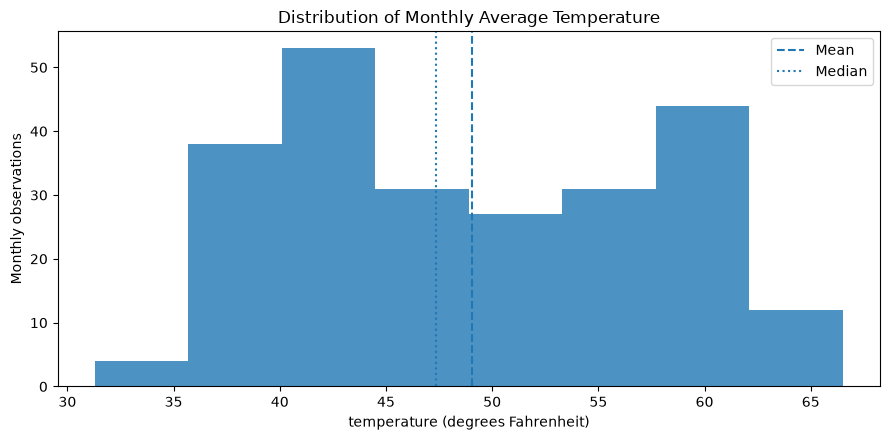

In [9]:
import matplotlib.pyplot as plt


if missing_value_count != 0:
    raise ValueError(
        "Distribution analysis requires the previously validated complete target; "
        f"observed missing values={missing_value_count}."
    )

if non_finite_non_missing_count != 0:
    raise ValueError(
        "Distribution analysis requires finite target values; "
        f"observed non-finite values={non_finite_non_missing_count}."
    )

observed_temperature = target_series.astype(float)

quantile_levels = {
    "p05": 0.05,
    "q1": 0.25,
    "median": 0.50,
    "q3": 0.75,
    "p95": 0.95,
}
target_quantiles = observed_temperature.quantile(
    list(quantile_levels.values())
)

q1 = float(target_quantiles.loc[0.25])
median = float(target_quantiles.loc[0.50])
q3 = float(target_quantiles.loc[0.75])
minimum = float(observed_temperature.min())
maximum = float(observed_temperature.max())

target_distribution_summary = pd.DataFrame(
    [
        ("Count", int(observed_temperature.count()), "months"),
        ("Mean", float(observed_temperature.mean()), TARGET_UNIT),
        ("Median", median, TARGET_UNIT),
        ("Sample standard deviation", float(observed_temperature.std(ddof=1)), TARGET_UNIT),
        ("Minimum", minimum, TARGET_UNIT),
        ("5th percentile", float(target_quantiles.loc[0.05]), TARGET_UNIT),
        ("First quartile (Q1)", q1, TARGET_UNIT),
        ("Third quartile (Q3)", q3, TARGET_UNIT),
        ("95th percentile", float(target_quantiles.loc[0.95]), TARGET_UNIT),
        ("Maximum", maximum, TARGET_UNIT),
        ("Interquartile range", q3 - q1, TARGET_UNIT),
        ("Observed range", maximum - minimum, TARGET_UNIT),
    ],
    columns=["Statistic", "Observed", "Unit"],
)

display(target_distribution_summary)

histogram_edges = np.histogram_bin_edges(
    observed_temperature.to_numpy(),
    bins="fd",
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(
    observed_temperature.to_numpy(),
    bins=histogram_edges,
    alpha=0.8,
)
ax.axvline(
    observed_temperature.mean(),
    linestyle="--",
    linewidth=1.5,
    label="Mean",
)
ax.axvline(
    median,
    linestyle=":",
    linewidth=1.5,
    label="Median",
)
ax.set_title("Distribution of Monthly Average Temperature")
ax.set_xlabel(f"{TARGET_NAME} ({TARGET_UNIT})")
ax.set_ylabel("Monthly observations")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Time-Series Evolution and Long-Term Trend Signals

The marginal distribution summarized above removes chronology. This section restores the temporal order and examines whether the **level of the series appears to evolve across the 1920–1939 record**.

Three complementary descriptive views are used:

- the complete monthly target series, preserving the observed month-to-month path;
- calendar-year mean temperatures, which summarize level across complete 12-month cycles; and
- a simple linear trend fitted to the 20 annual means, reported only as a descriptive long-term slope.

The annual aggregation is appropriate here because Section 7 established a complete regular monthly grid with exactly 12 observations per year, and Section 8 established that no target values require imputation. Annual means therefore compare equally populated calendar years without filling or dropping observations.

The linear annual-mean slope is **not** a forecasting model, a stationarity test, or proof that the underlying process follows a deterministic linear trend. Serial dependence, seasonality, non-linearity, structural changes, and finite-sample effects can all influence the apparent trajectory. Formal stationarity signals and structural-break diagnostics remain for later sections.

To complement the fitted slope without relying on a single line, the notebook also compares the average annual level during the first five years (`1920–1924`) with the last five years (`1935–1939`). This endpoint-window comparison is descriptive evidence only and does not establish causality or a permanent climate trend.

All calculations in this section are retrospective exploration of the full historical series. They must not be reused as globally fitted preprocessing or trend features inside future backtesting folds. Any learned detrending or trend component used for forecasting must be estimated only from the history available at each forecasting origin.

,Signal,Observed,Unit / interpretation
0,Annual periods summarized,20.000000,complete calendar years
1,Months per annual mean,12.000000,observations
2,"Mean annual level, 1920–1924",48.688333,degrees Fahrenheit
3,"Mean annual level, 1935–1939",49.445000,degrees Fahrenheit
4,Last-five minus first-five level,0.756667,degrees Fahrenheit
5,Linear slope across annual means,0.057086,degrees Fahrenheit per year
6,"Fitted linear change, 1920–1939",1.084643,degrees Fahrenheit
7,Lowest annual mean year,1922.000000,calendar year
8,Highest annual mean year,1921.000000,calendar year


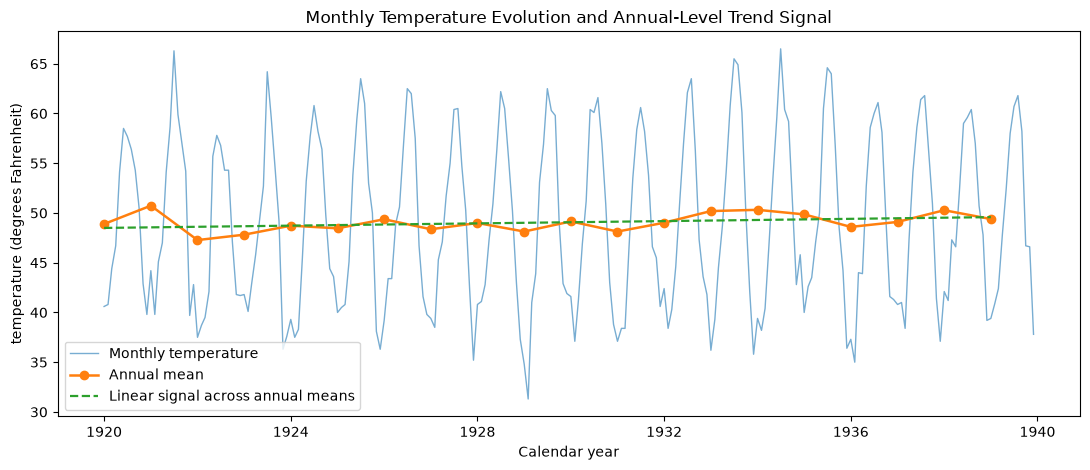

In [11]:
monthly_plot_index = target_series.index.to_timestamp(how="start")

annual_mean_temperature = (
    target_series
    .groupby(target_series.index.year)
    .mean()
    .astype(float)
)
annual_mean_temperature.index.name = "year"

if len(annual_mean_temperature) != 20:
    raise ValueError(
        "Long-term trend summary expects 20 complete calendar years; "
        f"observed {len(annual_mean_temperature)}."
    )

annual_observation_counts = target_series.groupby(target_series.index.year).count()

if not bool((annual_observation_counts == SOURCE_PERIODS_PER_YEAR).all()):
    raise ValueError(
        "Annual trend summaries require exactly 12 observed monthly values "
        "for every calendar year."
    )

annual_years = annual_mean_temperature.index.to_numpy(dtype=float)
annual_values = annual_mean_temperature.to_numpy(dtype=float)

annual_trend_slope, annual_trend_intercept = np.polyfit(
    annual_years,
    annual_values,
    deg=1,
)
annual_linear_trend = pd.Series(
    annual_trend_intercept + annual_trend_slope * annual_years,
    index=annual_mean_temperature.index,
    name="linear_trend",
)

first_five_year_mean = float(annual_mean_temperature.iloc[:5].mean())
last_five_year_mean = float(annual_mean_temperature.iloc[-5:].mean())
endpoint_window_difference = last_five_year_mean - first_five_year_mean
fitted_record_change = float(
    annual_linear_trend.iloc[-1] - annual_linear_trend.iloc[0]
)

long_term_level_summary = pd.DataFrame(
    [
        (
            "Annual periods summarized",
            len(annual_mean_temperature),
            "complete calendar years",
        ),
        (
            "Months per annual mean",
            SOURCE_PERIODS_PER_YEAR,
            "observations",
        ),
        (
            "Mean annual level, 1920–1924",
            first_five_year_mean,
            TARGET_UNIT,
        ),
        (
            "Mean annual level, 1935–1939",
            last_five_year_mean,
            TARGET_UNIT,
        ),
        (
            "Last-five minus first-five level",
            endpoint_window_difference,
            TARGET_UNIT,
        ),
        (
            "Linear slope across annual means",
            float(annual_trend_slope),
            f"{TARGET_UNIT} per year",
        ),
        (
            "Fitted linear change, 1920–1939",
            fitted_record_change,
            TARGET_UNIT,
        ),
        (
            "Lowest annual mean year",
            int(annual_mean_temperature.idxmin()),
            "calendar year",
        ),
        (
            "Highest annual mean year",
            int(annual_mean_temperature.idxmax()),
            "calendar year",
        ),
    ],
    columns=["Signal", "Observed", "Unit / interpretation"],
)

display(long_term_level_summary)

annual_plot_index = pd.PeriodIndex(
    annual_mean_temperature.index.astype(str),
    freq="Y",
).to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(
    monthly_plot_index,
    target_series.to_numpy(dtype=float),
    linewidth=1.0,
    alpha=0.6,
    label="Monthly temperature",
)
ax.plot(
    annual_plot_index,
    annual_mean_temperature.to_numpy(),
    marker="o",
    linewidth=1.8,
    label="Annual mean",
)
ax.plot(
    annual_plot_index,
    annual_linear_trend.to_numpy(),
    linestyle="--",
    linewidth=1.6,
    label="Linear signal across annual means",
)
ax.set_title("Monthly Temperature Evolution and Annual-Level Trend Signal")
ax.set_xlabel("Calendar year")
ax.set_ylabel(f"{TARGET_NAME} ({TARGET_UNIT})")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Seasonal Structure and Calendar-Month Profiles

The source frequency establishes a 12-month calendar cycle, but frequency alone does not prove that the target contains a stable seasonal signal. This section therefore compares the same calendar months across the 20 complete years of observation.

Because temporal integrity and value completeness have already been validated, every calendar month contributes exactly 20 observed temperatures to its month-of-year profile. No interpolation, imputation, resampling, detrending, seasonal adjustment, or transformation is required for this descriptive comparison.

For each calendar month, the notebook summarizes:

- observation count;
- mean temperature;
- median temperature;
- sample standard deviation;
- interquartile range;
- minimum; and
- maximum.

The month with the highest cross-year mean and the month with the lowest cross-year mean are also identified. Their difference is reported as the **calendar-month mean range**. This is a descriptive seasonal amplitude signal only; it is not the formal seasonal-strength statistic evaluated in the decomposition section that follows.

A year-by-month profile plot is used to examine whether a broadly similar within-year shape recurs across calendar years while retaining visibility into interannual variation. The cross-year monthly mean is overlaid as a descriptive reference.

Calendar-month summaries use the full historical series only for exploration. They must not be reused as globally fitted seasonal encodings, imputers, adjustments, or forecasting features during later model evaluation. Any learned seasonal component used in forecasting must be estimated strictly from the historical observations available at each forecasting origin.

This section does not yet choose a seasonal baseline, specify seasonal differencing, fit Holt-Winters/ETS or SARIMA models, quantify decomposition-based seasonal strength, or prove that a seasonal forecasting model is required.

,month_name,count,mean,median,std,q1,q3,iqr,minimum,maximum
calendar_month,,,,,,,,,,
1,Jan,20,39.695,39.70,2.282998,38.775,41.000,2.225,34.8,44.2
2,Feb,20,39.190,39.55,2.702221,38.350,40.925,2.575,31.3,43.4
3,Mar,20,42.195,42.60,2.555175,40.375,44.100,3.725,38.3,47.3
4,Apr,20,46.290,46.80,1.688007,45.400,47.150,1.750,42.1,48.9
5,May,20,52.560,52.90,1.675646,51.125,53.875,2.750,49.2,55.7
6,Jun,20,58.040,58.45,1.924742,56.975,59.100,2.125,52.7,60.8
7,Jul,20,61.900,61.75,2.636784,60.325,63.675,3.350,56.8,66.5
8,Aug,20,60.520,60.50,2.461407,59.825,61.800,1.975,54.3,64.9
9,Sep,20,56.480,56.60,2.007774,54.625,57.650,3.025,53.0,60.1


,Signal,Observed,Unit / interpretation
0,Complete annual cycles,20,years
1,Observations per calendar month,20,observations
2,Highest mean calendar month,July,descriptive cross-year mean
3,Lowest mean calendar month,February,descriptive cross-year mean
4,Calendar-month mean range,22.71,degrees Fahrenheit
5,Formal seasonal strength,not evaluated here,reserved for decomposition analysis


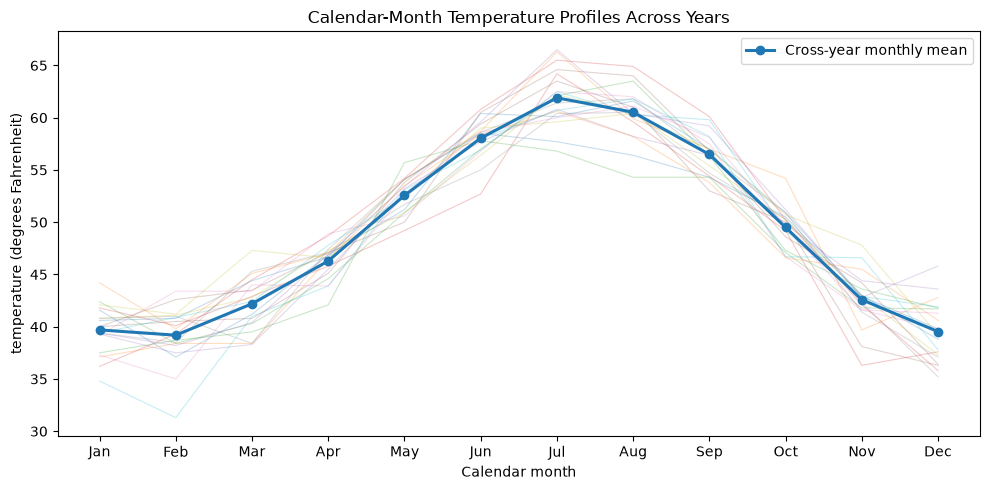

In [12]:
import calendar


calendar_month = pd.Index(
    target_series.index.month,
    name="calendar_month",
)

month_profile_frame = pd.DataFrame(
    {
        TARGET_NAME: target_series.to_numpy(dtype=float),
        "calendar_month": calendar_month.to_numpy(),
        "calendar_year": target_series.index.year,
    },
    index=target_series.index,
)

monthly_group = month_profile_frame.groupby(
    "calendar_month",
    sort=True,
)[TARGET_NAME]

calendar_month_profile = pd.DataFrame(
    {
        "count": monthly_group.count(),
        "mean": monthly_group.mean(),
        "median": monthly_group.median(),
        "std": monthly_group.std(ddof=1),
        "q1": monthly_group.quantile(0.25),
        "q3": monthly_group.quantile(0.75),
        "minimum": monthly_group.min(),
        "maximum": monthly_group.max(),
    }
)

calendar_month_profile["iqr"] = (
    calendar_month_profile["q3"] - calendar_month_profile["q1"]
)
calendar_month_profile["month_name"] = [
    calendar.month_abbr[month]
    for month in calendar_month_profile.index
]

calendar_month_profile = calendar_month_profile[
    [
        "month_name",
        "count",
        "mean",
        "median",
        "std",
        "q1",
        "q3",
        "iqr",
        "minimum",
        "maximum",
    ]
]

expected_years_per_month = int(
    len(target_series) / SOURCE_PERIODS_PER_YEAR
)

if expected_years_per_month != 20:
    raise ValueError(
        "Calendar-month profiling expects 20 complete annual cycles; "
        f"observed {expected_years_per_month}."
    )

if not bool(
    (
        calendar_month_profile["count"]
        == expected_years_per_month
    ).all()
):
    raise ValueError(
        "Each calendar month must contain exactly one observation "
        "from every complete source year."
    )

warmest_month_number = int(
    calendar_month_profile["mean"].idxmax()
)
coolest_month_number = int(
    calendar_month_profile["mean"].idxmin()
)

calendar_month_mean_range = float(
    calendar_month_profile["mean"].max()
    - calendar_month_profile["mean"].min()
)

seasonal_profile_summary = pd.DataFrame(
    [
        (
            "Complete annual cycles",
            expected_years_per_month,
            "years",
        ),
        (
            "Observations per calendar month",
            int(calendar_month_profile["count"].iloc[0]),
            "observations",
        ),
        (
            "Highest mean calendar month",
            calendar.month_name[warmest_month_number],
            "descriptive cross-year mean",
        ),
        (
            "Lowest mean calendar month",
            calendar.month_name[coolest_month_number],
            "descriptive cross-year mean",
        ),
        (
            "Calendar-month mean range",
            calendar_month_mean_range,
            TARGET_UNIT,
        ),
        (
            "Formal seasonal strength",
            "not evaluated here",
            "reserved for decomposition analysis",
        ),
    ],
    columns=["Signal", "Observed", "Unit / interpretation"],
)

display(calendar_month_profile)
display(seasonal_profile_summary)

year_month_matrix = (
    month_profile_frame
    .pivot(
        index="calendar_month",
        columns="calendar_year",
        values=TARGET_NAME,
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
for year in year_month_matrix.columns:
    ax.plot(
        year_month_matrix.index,
        year_month_matrix[year].to_numpy(),
        linewidth=0.8,
        alpha=0.25,
    )

ax.plot(
    calendar_month_profile.index,
    calendar_month_profile["mean"].to_numpy(),
    marker="o",
    linewidth=2.2,
    label="Cross-year monthly mean",
)
ax.set_title("Calendar-Month Temperature Profiles Across Years")
ax.set_xlabel("Calendar month")
ax.set_ylabel(f"{TARGET_NAME} ({TARGET_UNIT})")
ax.set_xticks(range(1, SOURCE_PERIODS_PER_YEAR + 1))
ax.set_xticklabels(
    [
        calendar.month_abbr[month]
        for month in range(1, SOURCE_PERIODS_PER_YEAR + 1)
    ]
)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Decomposition and Trend/Seasonal Strength

The calendar-month profiles above show a large and recurrent within-year temperature cycle, but descriptive month averages do not separate long-term level movement from seasonal structure and residual variation. This section therefore applies an **additive STL decomposition** to the complete canonical monthly series.

STL is used here as an exploratory decomposition, not as a forecasting model. The decomposition period is fixed at the authenticated source frequency of **12 months**. An additive representation is appropriate for this diagnostic because the target is measured on an interval scale in degrees Fahrenheit and this study has not established evidence that seasonal variation should scale multiplicatively with the series level.

The decomposition separates the observed series into:

- a smooth trend component;
- a recurring seasonal component; and
- a remainder containing variation not represented by those two components.

The notebook also reports descriptive **trend strength** and **seasonal strength** statistics using variance ratios:

- trend strength = `max(0, 1 - Var(remainder) / Var(trend + remainder))`;
- seasonal strength = `max(0, 1 - Var(remainder) / Var(seasonal + remainder))`.

Both statistics are bounded to `[0, 1]` for interpretation, where values nearer 1 indicate that the corresponding component explains a larger share of variation relative to the remainder. They are descriptive diagnostics rather than hypothesis tests or model-selection scores.

The decomposition is deliberately fitted with `robust=False`. Robust reweighting could downweight unusual observations before the dedicated anomaly analysis has established whether such treatment is justified. Potential anomalies and structural breaks remain explicit subjects of Section 16.

This full-series STL fit is valid only for retrospective exploration. It is **not leakage-safe preprocessing for forecasting evaluation** because observations across the full record contribute to the fitted decomposition. If detrending, seasonal adjustment, or decomposition-derived features are later used by a forecasting model, they must be learned independently inside each allowed historical window or forecasting origin.

No model family, differencing order, seasonal differencing rule, baseline, forecast horizon, or stationarity conclusion is selected in this section.

,Diagnostic,Observed,Interpretation / unit
0,Decomposition method,STL additive,retrospective exploratory decomposition
1,Seasonal period,12,months
2,Robust reweighting,False,disabled before dedicated anomaly analysis
3,Trend strength,0.241372,"bounded descriptive strength [0, 1]"
4,Seasonal strength,0.959733,"bounded descriptive strength [0, 1]"
5,Seasonal component range,26.832091,degrees Fahrenheit
6,Trend component endpoint change,0.927661,degrees Fahrenheit
7,Remainder sample standard deviation,1.708214,degrees Fahrenheit


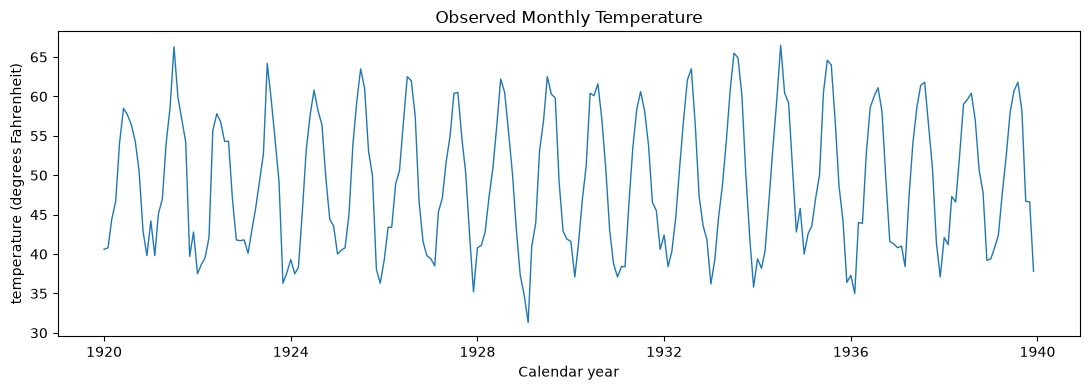

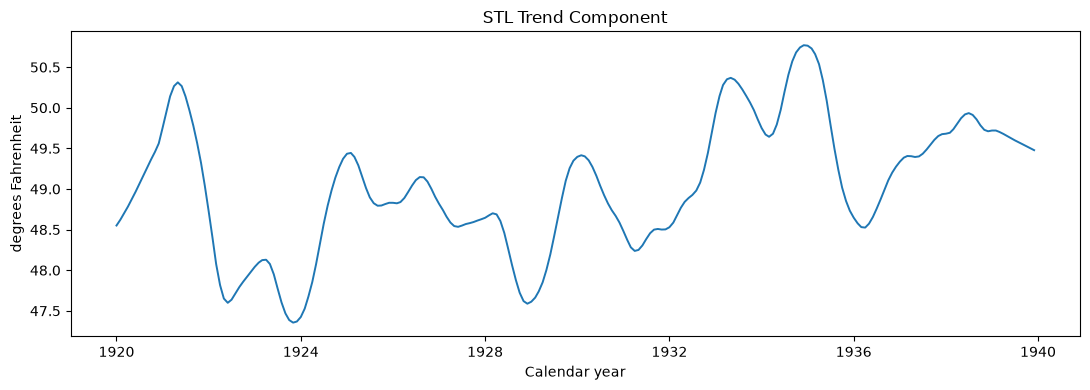

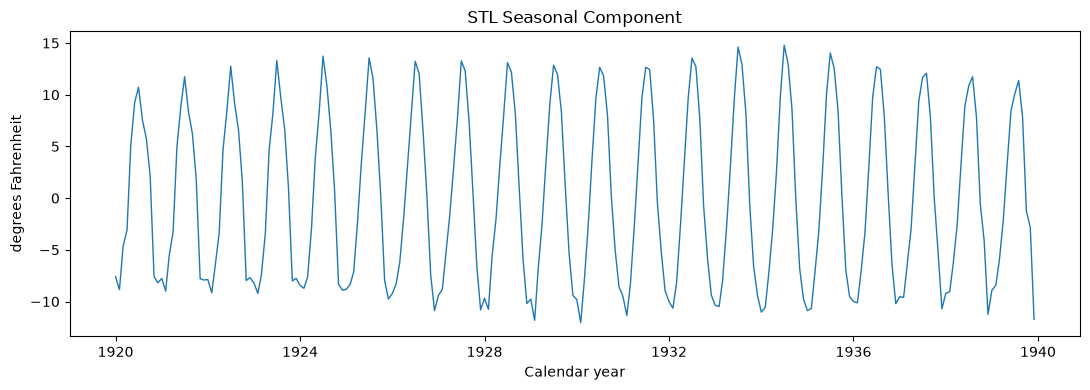

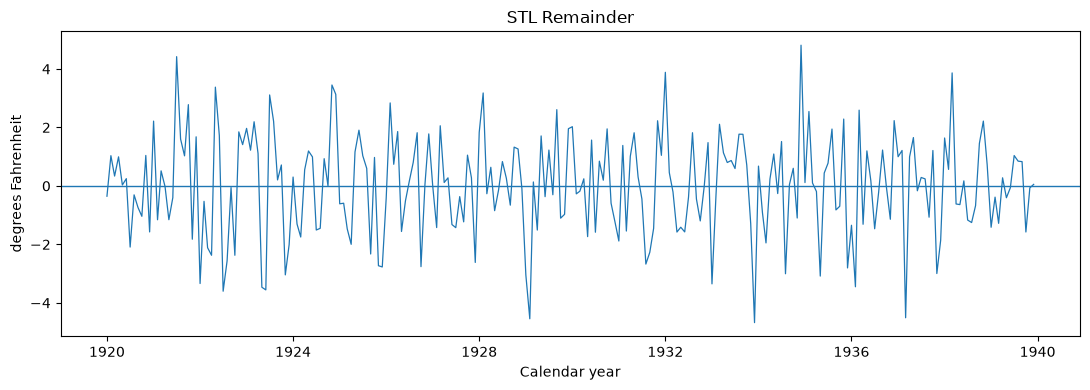

In [13]:
from statsmodels.tsa.seasonal import STL


DECOMPOSITION_PERIOD = SOURCE_PERIODS_PER_YEAR

if DECOMPOSITION_PERIOD != 12:
    raise ValueError(
        "The decomposition period must match the authenticated monthly "
        f"frequency; observed {DECOMPOSITION_PERIOD}."
    )

if len(target_series) < 2 * DECOMPOSITION_PERIOD:
    raise ValueError(
        "STL exploration requires at least two complete seasonal cycles."
    )

if missing_value_count != 0 or non_finite_non_missing_count != 0:
    raise ValueError(
        "STL exploration requires the complete finite target validated "
        "in Section 8."
    )

stl_result = STL(
    target_series.to_numpy(dtype=float),
    period=DECOMPOSITION_PERIOD,
    robust=False,
).fit()

decomposition_trend = pd.Series(
    stl_result.trend,
    index=target_series.index,
    name="trend",
)
decomposition_seasonal = pd.Series(
    stl_result.seasonal,
    index=target_series.index,
    name="seasonal",
)
decomposition_remainder = pd.Series(
    stl_result.resid,
    index=target_series.index,
    name="remainder",
)

reconstructed_values = (
    decomposition_trend
    + decomposition_seasonal
    + decomposition_remainder
)

if not np.allclose(
    reconstructed_values.to_numpy(),
    target_series.to_numpy(dtype=float),
    rtol=1e-10,
    atol=1e-10,
):
    raise ValueError(
        "STL components do not reconstruct the observed target within tolerance."
    )


def _variance_strength(
    component: pd.Series,
    remainder: pd.Series,
) -> float:
    remainder_variance = float(
        np.var(remainder.to_numpy(dtype=float), ddof=1)
    )
    combined_variance = float(
        np.var(
            (component + remainder).to_numpy(dtype=float),
            ddof=1,
        )
    )

    if not np.isfinite(combined_variance) or combined_variance <= 0:
        raise ValueError(
            "Component strength requires positive finite comparison variance."
        )

    strength = 1.0 - (remainder_variance / combined_variance)
    return float(np.clip(strength, 0.0, 1.0))


trend_strength = _variance_strength(
    decomposition_trend,
    decomposition_remainder,
)
seasonal_strength = _variance_strength(
    decomposition_seasonal,
    decomposition_remainder,
)

seasonal_component_range = float(
    decomposition_seasonal.max() - decomposition_seasonal.min()
)
trend_component_change = float(
    decomposition_trend.iloc[-1] - decomposition_trend.iloc[0]
)
remainder_standard_deviation = float(
    decomposition_remainder.std(ddof=1)
)

decomposition_summary = pd.DataFrame(
    [
        (
            "Decomposition method",
            "STL additive",
            "retrospective exploratory decomposition",
        ),
        (
            "Seasonal period",
            DECOMPOSITION_PERIOD,
            "months",
        ),
        (
            "Robust reweighting",
            False,
            "disabled before dedicated anomaly analysis",
        ),
        (
            "Trend strength",
            trend_strength,
            "bounded descriptive strength [0, 1]",
        ),
        (
            "Seasonal strength",
            seasonal_strength,
            "bounded descriptive strength [0, 1]",
        ),
        (
            "Seasonal component range",
            seasonal_component_range,
            TARGET_UNIT,
        ),
        (
            "Trend component endpoint change",
            trend_component_change,
            TARGET_UNIT,
        ),
        (
            "Remainder sample standard deviation",
            remainder_standard_deviation,
            TARGET_UNIT,
        ),
    ],
    columns=["Diagnostic", "Observed", "Interpretation / unit"],
)

display(decomposition_summary)

decomposition_plot_index = target_series.index.to_timestamp(how="start")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    decomposition_plot_index,
    target_series.to_numpy(dtype=float),
    linewidth=1.0,
)
ax.set_title("Observed Monthly Temperature")
ax.set_xlabel("Calendar year")
ax.set_ylabel(f"{TARGET_NAME} ({TARGET_UNIT})")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    decomposition_plot_index,
    decomposition_trend.to_numpy(dtype=float),
    linewidth=1.4,
)
ax.set_title("STL Trend Component")
ax.set_xlabel("Calendar year")
ax.set_ylabel(TARGET_UNIT)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    decomposition_plot_index,
    decomposition_seasonal.to_numpy(dtype=float),
    linewidth=1.0,
)
ax.set_title("STL Seasonal Component")
ax.set_xlabel("Calendar year")
ax.set_ylabel(TARGET_UNIT)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    decomposition_plot_index,
    decomposition_remainder.to_numpy(dtype=float),
    linewidth=0.9,
)
ax.axhline(0.0, linewidth=1.0)
ax.set_title("STL Remainder")
ax.set_xlabel("Calendar year")
ax.set_ylabel(TARGET_UNIT)
plt.tight_layout()
plt.show()

## 14. Autocorrelation and Lag Dependence

## 15. Stationarity and Transformation/Differencing Signals

## 16. Outliers, Anomalies, and Structural-Break Signals

## 17. Forecast Horizon and Final-Holdout Feasibility

## 18. Forecasting Baselines and Forecastability Considerations

## 19. Temporal Leakage and Evaluation-Boundary Risks

## 20. Key Exploratory Insights

## 21. Preparation and Backtesting Decisions

## 22. Exploration Handoff and Next Steps